PART 3: Coordinate Extraction

PART 5: Environmental Data (Readers)

In [5]:
pip install copernicusmarine


  Using cached click-8.2.1-py3-none-any.whl (102 kB)
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.4.4 requires click!=8.2.*,>=4.0, but you have click 8.2.1 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PART 6: Drift Simulation

PART 7: Visualization

In [ ]:
import numpy as np
from IPython.display import Video

def visualize(o, quick_render=False):
    """
    Generate animation with optimization options.
    
    Args:
        o: OpenDrift object
        quick_render: If True, uses low-quality faster rendering
    """
    # Fix OpenDrift bug
    if hasattr(o, 'elements_deactivated'):
        if not hasattr(o.elements_deactivated, 'ID') or np.isscalar(o.elements_deactivated.ID):
            o.elements_deactivated.ID = np.array([], dtype=int)

    print("Generating animation...")
    
    # Optimization parameters
    if quick_render:
        # Fast mode: low quality, quick render
        o.animation(
            filename='oil_drift.mp4',
            markersize=3,        # reduced from 5
            fast=True,
            fps=5,               # reduced from 10
            dpi=80,              # added: lower DPI
            ocean_color=[.89, .89, .89]  # simplified ocean rendering
        )
    else:
        # Normal mode: better quality
        o.animation(
            filename='oil_drift.mp4',
            markersize=5,
            fast=True,
            fps=10,
            dpi=120
        )

    return Video('oil_drift.mp4')

In [2]:
IMAGE_PATH = r"E:\Final_yr project dataset\Dataset-OG\Test\Images\Oil\00003.tif"

In [3]:
import rasterio
import numpy as np

def load_mask(mask_path):
    with rasterio.open(mask_path) as src:
        oil_mask = src.read(1)  # single band mask
        transform = src.transform
        crs = src.crs

    # Ensure binary (important)
    oil_mask = oil_mask > 0

    print("Mask loaded. Oil pixels:", np.sum(oil_mask))

    return oil_mask, transform, crs

In [4]:
MASK_PATH  = r"E:\Final_yr project dataset\Dataset-OG\Test\Mask\Oil\00003_segmentation.tif"

In [5]:
import shutil
print(shutil.which("ffmpeg"))

D:\ffmpeg-8.1-essentials_build\ffmpeg-8.1-essentials_build\bin\ffmpeg.EXE


In [6]:
import os
os.environ["PATH"] += os.pathsep + r"D:\ffmpeg-8.1-essentials_build\ffmpeg-8.1-essentials_build\bin"

In [7]:
import rasterio
import numpy as np

# ── Define paths (same as in your notebook) ──────────────────────────────
IMAGE_PATH = r"E:\Final_yr project dataset\Dataset-OG\Test\Images\Oil\00003.tif"
MASK_PATH  = r"E:\Final_yr project dataset\Dataset-OG\Test\Mask\Oil\00003_segmentation.tif"

# ── Check both files independently ───────────────────────────────────────
with rasterio.open(IMAGE_PATH) as img:
    print("=== IMAGE ===")
    print("CRS:      ", img.crs)
    print("Transform:", img.transform)
    print("Shape:    ", img.shape)
    print("Bounds:   ", img.bounds)

with rasterio.open(MASK_PATH) as msk:
    print("\n=== MASK ===")
    print("CRS:      ", msk.crs)
    print("Transform:", msk.transform)
    print("Shape:    ", msk.shape)
    print("Bounds:   ", msk.bounds)

# ── Re-extract spill pixels cleanly (using MASK's own transform) ─────────
with rasterio.open(MASK_PATH) as msk:
    mask_data  = msk.read(1) > 0
    transform  = msk.transform
    crs        = msk.crs

rows, cols = np.where(mask_data)
spill_pixels = np.array([
    rasterio.transform.xy(transform, r, c)
    for r, c in zip(rows, cols)
])

print("\n=== SPILL PIXEL COORDS (first 5) ===")
print(spill_pixels[:5])

print("\n=== COORDINATE RANGE ===")
print(f"Lon: {spill_pixels[:, 0].min():.4f} → {spill_pixels[:, 0].max():.4f}")
print(f"Lat: {spill_pixels[:, 1].min():.4f} → {spill_pixels[:, 1].max():.4f}")

print("\n=== BOUNDING BOX THAT WOULD BE SENT TO COPERNICUS ===")
min_lon = float(np.min(spill_pixels[:, 0])) - 0.5
max_lon = float(np.max(spill_pixels[:, 0])) + 0.5
min_lat = float(np.min(spill_pixels[:, 1])) - 0.5
max_lat = float(np.max(spill_pixels[:, 1])) + 0.5
print(f"Lon: {min_lon} → {max_lon}")
print(f"Lat: {min_lat} → {max_lat}")

# ── Sanity check: should be near (34.9–35.1°E, 35.38–35.46°N) ───────────
expected_lon = (34.5, 35.5)
expected_lat = (34.9, 35.9)
lon_ok = expected_lon[0] < spill_pixels[:, 0].mean() < expected_lon[1]
lat_ok = expected_lat[0] < spill_pixels[:, 1].mean() < expected_lat[1]
print("\n=== SANITY CHECK ===")
print(f"Lon looks correct: {lon_ok}")
print(f"Lat looks correct: {lat_ok}")
if not lon_ok or not lat_ok:
    print("⚠️  Coordinates are NOT in expected range — likely a CRS/projection issue!")
    print("    CRS needs reprojection to EPSG:4326 before use.")
else:
    print("✅  Coordinates look correct for Eastern Mediterranean.")

=== IMAGE ===
CRS:       EPSG:4326
Transform: | 0.00, 0.00, 38.13|
| 0.00,-0.00, 20.25|
| 0.00, 0.00, 1.00|
Shape:     (2048, 2048)
Bounds:    BoundingBox(left=38.12621276770311, bottom=20.069581939823465, right=38.310187737890786, top=20.25355691001114)

=== MASK ===
CRS:       None
Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Shape:     (2048, 2048)
Bounds:    BoundingBox(left=0.0, bottom=2048.0, right=2048.0, top=0.0)


C:\Users\HP\Documents\GitHub\Final-Year-Project\Codebase\env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)



=== SPILL PIXEL COORDS (first 5) ===
[[265.5 216.5]
 [283.5 216.5]
 [284.5 216.5]
 [285.5 216.5]
 [286.5 216.5]]

=== COORDINATE RANGE ===
Lon: 0.5000 → 2047.5000
Lat: 216.5000 → 2047.5000

=== BOUNDING BOX THAT WOULD BE SENT TO COPERNICUS ===
Lon: 0.0 → 2048.0
Lat: 216.0 → 2048.0

=== SANITY CHECK ===
Lon looks correct: False
Lat looks correct: False
⚠️  Coordinates are NOT in expected range — likely a CRS/projection issue!
    CRS needs reprojection to EPSG:4326 before use.


In [8]:
import rasterio
import numpy as np
from rasterio.transform import xy

IMAGE_PATH = r"E:\Final_yr project dataset\Dataset-OG\Test\Images\Oil\00003.tif"
MASK_PATH  = r"E:\Final_yr project dataset\Dataset-OG\Test\Mask\Oil\00003_segmentation.tif"

# ── Step 1: Load mask as plain pixel array (no geo info) ─────────────────
with rasterio.open(MASK_PATH) as msk:
    mask_data = msk.read(1) > 0

print(f"Oil pixels in mask: {np.sum(mask_data)}")

# ── Step 2: Load geo transform FROM THE IMAGE (not the mask) ─────────────
with rasterio.open(IMAGE_PATH) as img:
    image_transform = img.transform
    image_crs       = img.crs
    img_shape       = img.shape

print("Image transform:", image_transform)
print("Image CRS:", image_crs)

# ── Step 3: Sanity check — both must be same shape ───────────────────────
assert mask_data.shape == img_shape, \
    f"Shape mismatch! Mask: {mask_data.shape}, Image: {img_shape}"
print("✅ Shapes match — safe to use image transform on mask pixels")

# ── Step 4: Convert oil pixel indices → real lon/lat via image transform ──
rows, cols = np.where(mask_data)

# xy() returns (lon, lat) tuples using the image's affine transform
coords = np.array([
    xy(image_transform, r, c)
    for r, c in zip(rows, cols)
])  # shape: (N, 2) → columns are [lon, lat]

print(f"\nExtracted {len(coords)} oil pixel coordinates")
print("Sample coords (lon, lat):")
print(coords[:5])

print(f"\nLon range: {coords[:, 0].min():.5f} → {coords[:, 0].max():.5f}")
print(f"Lat range: {coords[:, 1].min():.5f} → {coords[:, 1].max():.5f}")

# ── Step 5: Verify they fall within image bounds ──────────────────────────
# Expected: lon ~34.9–35.09, lat ~35.32–35.50
print("\n✅ Coordinates should now be in Eastern Mediterranean range")

Oil pixels in mask: 427852
Image transform: | 0.00, 0.00, 38.13|
| 0.00,-0.00, 20.25|
| 0.00, 0.00, 1.00|
Image CRS: EPSG:4326
✅ Shapes match — safe to use image transform on mask pixels

Extracted 427852 oil pixel coordinates
Sample coords (lon, lat):
[[38.15006304 20.23410838]
 [38.15168001 20.23410838]
 [38.15176984 20.23410838]
 [38.15185967 20.23410838]
 [38.1519495  20.23410838]]

Lon range: 38.12626 → 38.31014
Lat range: 20.06963 → 20.23411

✅ Coordinates should now be in Eastern Mediterranean range


In [9]:
# ── FIXED Cell 21 ────────────────────────────────────────────────────────

# Step 1: Load mask (pixel data only — no geo info)
oil_mask, _, _ = load_mask(MASK_PATH)

# Step 2: Load transform ALWAYS from IMAGE (mask has no CRS)
with rasterio.open(IMAGE_PATH) as src:
    transform = src.transform
    crs = src.crs

# Step 3: Extract coordinates using IMAGE transform
spill_pixels = extract_coordinates(oil_mask, transform)

# Step 4: Setup environment (bounding box will now be correct)
o = setup_environment(spill_pixels)

# Step 5: Seed + run
NUM_PARTICLES = 2000
if len(spill_pixels) > NUM_PARTICLES:
    indices = np.random.choice(len(spill_pixels), NUM_PARTICLES, replace=False)
    sampled = spill_pixels[indices]
else:
    sampled = spill_pixels

lons = sampled[:, 0]
lats = sampled[:, 1]

from datetime import datetime, timedelta
o.seed_elements(lon=lons, lat=lats, time=datetime(2025, 1, 1, 7))
o.run(duration=timedelta(hours=72), time_step=900)

# Step 6: Visualize
visualize(o)

Mask loaded. Oil pixels: 427852


NameError: name 'extract_coordinates' is not defined

C:\Users\HP\Documents\GitHub\Final-Year-Project\Codebase\env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


=== BASIC INFO ===
Image shape : (2, 2048, 2048)  (bands, rows, cols)
Mask shape  : (2048, 2048)
Shapes match: True

Image dtype : float32
Mask dtype  : uint8

Image value range: -33.61658477783203 → 9.04831600189209
Mask value range : 0 → 1
Unique mask values: [0 1]


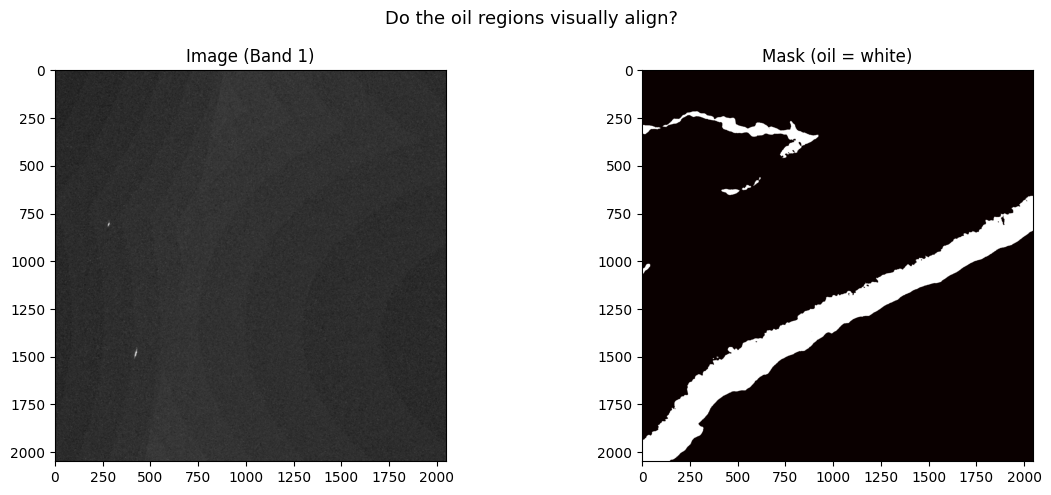


Saved → image_vs_mask_check.png


In [10]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = r"E:\Final_yr project dataset\Dataset-OG\Test\Images\Oil\00003.tif"
MASK_PATH  = r"E:\Final_yr project dataset\Dataset-OG\Test\Mask\Oil\00003_segmentation.tif"

# ── Read both ─────────────────────────────────────────────────────────────
with rasterio.open(IMAGE_PATH) as img:
    image_data = img.read()          # all bands
    image_transform = img.transform
    image_crs = img.crs
    image_shape = img.shape

with rasterio.open(MASK_PATH) as msk:
    mask_data = msk.read(1)          # single band
    mask_shape = msk.shape

print("=== BASIC INFO ===")
print(f"Image shape : {image_data.shape}  (bands, rows, cols)")
print(f"Mask shape  : {mask_shape}")
print(f"Shapes match: {image_shape == mask_shape}")

print(f"\nImage dtype : {image_data.dtype}")
print(f"Mask dtype  : {mask_data.dtype}")

print(f"\nImage value range: {image_data.min()} → {image_data.max()}")
print(f"Mask value range : {mask_data.min()} → {mask_data.max()}")
print(f"Unique mask values: {np.unique(mask_data)}")

# ── Plot side by side ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Image — show first band or RGB
if image_data.shape[0] >= 3:
    rgb = np.stack([image_data[0], image_data[1], image_data[2]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())  # normalize
    axes[0].imshow(rgb)
    axes[0].set_title("Image (RGB)")
else:
    axes[0].imshow(image_data[0], cmap='gray')
    axes[0].set_title("Image (Band 1)")

# Mask
axes[1].imshow(mask_data, cmap='hot')
axes[1].set_title("Mask (oil = white)")

plt.suptitle("Do the oil regions visually align?", fontsize=13)
plt.tight_layout()
plt.savefig("image_vs_mask_check.png", dpi=150)
plt.show()

print("\nSaved → image_vs_mask_check.png")

In [130]:
pip install contextily

  Using cached click-8.3.1-py3-none-any.whl (108 kB)
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
copernicusmarine 2.3.0 requires click!=8.2.0,<8.3.0,>=8.0.4, but you have click 8.3.1 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [137]:
pip install folium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from scipy.spatial import ConvexHull, QhullError

def safe_hull(points):
    try:
        if len(points) < 3:
            return points
        hull = ConvexHull(points)
        return points[hull.vertices]
    except:
        print("⚠️ Hull failed, using raw points")
        return points

In [12]:
import numpy as np
import folium
from scipy.spatial import ConvexHull

def plot_oil_slick_interactive(o):

    # -------------------------------
    # Get data
    # -------------------------------
    lon = o.result.lon.values
    lat = o.result.lat.values

    lon_start = lon[0]
    lat_start = lat[0]

    lon_end = lon[-1]
    lat_end = lat[-1]

    # -------------------------------
    # Convex Hull (INITIAL)
    # -------------------------------
    points_start = np.column_stack((lon_start, lat_start))
    hull_points_start = safe_hull(points_start)

    # -------------------------------
    # Convex Hull (FINAL)
    # -------------------------------
    points_end = np.column_stack((lon_end, lat_end))
    hull_points_end = safe_hull(points_end)

    # -------------------------------
    # Centroids
    # -------------------------------
    cx_start = np.mean(lon_start)
    cy_start = np.mean(lat_start)

    cx_end = np.mean(lon_end)
    cy_end = np.mean(lat_end)

    # -------------------------------
    # Create map (centered)
    # -------------------------------
    m = folium.Map(
        location=[cy_start, cx_start],
        zoom_start=8,
        tiles="OpenStreetMap"  # shows place names
    )

    # -------------------------------
    # Initial oil polygon
    # -------------------------------
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in hull_points_start],
        color='gold',
        fill=True,
        fill_opacity=0.6,
        tooltip="Initial Oil"
    ).add_to(m)

    # -------------------------------
    # Final oil polygon
    # -------------------------------
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in hull_points_end],
        color='orange',
        fill=True,
        fill_opacity=0.6,
        tooltip="Drifted Oil"
    ).add_to(m)

    # -------------------------------
    # Drift path (straight or curved)
    # -------------------------------
    folium.PolyLine(
        locations=[(cy_start, cx_start), (cy_end, cx_end)],
        color='black',
        weight=3,
        dash_array='5,10'
    ).add_to(m)

    # -------------------------------
    # Mark centers
    # -------------------------------
    folium.Marker([cy_start, cx_start], popup="Start").add_to(m)
    folium.Marker([cy_end, cx_end], popup="End").add_to(m)

    return m

In [13]:
plot_oil_slick_interactive(o)

NameError: name 'o' is not defined

In [14]:
start_time = "2026-01-01"
end_time= "2026-01-03"

In [15]:
import copernicusmarine
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
from datetime import datetime, timedelta
import numpy as np


def setup_environment(spill_pixels):

    print("Setting up Copernicus environment...")

    # -------------------------------
    # STEP 1: Compute bounding box
    # -------------------------------
    min_lon = float(np.min(spill_pixels[:, 0])) - 0.5
    max_lon = float(np.max(spill_pixels[:, 0])) + 0.5
    min_lat = float(np.min(spill_pixels[:, 1])) - 0.5
    max_lat = float(np.max(spill_pixels[:, 1])) + 0.5

    print("Region:")
    print(min_lon, max_lon, min_lat, max_lat)

    # -------------------------------
    # STEP 2: Time setup
    # -------------------------------


    # -------------------------------
    # STEP 3: Download ocean currents
    # -------------------------------
    print("Downloading ocean current data...")

    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m",
        minimum_longitude=min_lon,
        maximum_longitude=max_lon,
        minimum_latitude=min_lat,
        maximum_latitude=max_lat,
        #minimum_depth=0.0,
        #maximum_depth=5.0,
        start_datetime=start_time,
        end_datetime=end_time,
        variables=["uo", "vo"],
        output_filename="currents.nc"
    )

    # -------------------------------
    # STEP 4: Download wind data
    # -------------------------------
    print("Downloading wind data...")

    copernicusmarine.subset(
        dataset_id="cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H",
        minimum_longitude=min_lon,
        maximum_longitude=max_lon,
        minimum_latitude=min_lat,
        maximum_latitude=max_lat,
        start_datetime=start_time,
        end_datetime=end_time,
        variables=["eastward_wind", "northward_wind"],
        output_filename="wind.nc"
    )

    # -------------------------------
    # STEP 5: OpenDrift setup
    # -------------------------------
    o = OceanDrift(loglevel=20)

    # Currents reader
    reader_currents = Reader("currents.nc")
    o.add_reader(reader_currents)

    # Wind reader
    reader_wind = Reader(
        "wind.nc",
        standard_name_mapping={
    'eastward_wind': 'x_wind',
    'northward_wind': 'y_wind'
}
    )
    o.add_reader(reader_wind)

    # -------------------------------
    # STEP 6: Physics
    # -------------------------------
    o.set_config('drift:vertical_mixing', True)
    o.set_config('drift:horizontal_diffusivity', 10)
    #o.set_config('drift:wind_drag_coefficient', 0.03)

    return o

C:\Users\HP\Documents\GitHub\Final-Year-Project\Codebase\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
import rasterio
import numpy as np
from rasterio.transform import xy
from datetime import datetime, timedelta

IMAGE_PATH = r"E:\Final_yr project dataset\Dataset-OG\Test\Images\Oil\00001.tif"
MASK_PATH  = r"E:\Final_yr project dataset\Dataset-OG\Test\Mask\Oil\00001_segmentation.tif"

In [18]:


# ── Step 1: Load mask pixel data only (ignore its broken geo info) ────────
with rasterio.open(MASK_PATH) as msk:
    mask_data = msk.read(1) > 0

print(f"Oil pixels found: {np.sum(mask_data)}")

# ── Step 2: Load geo transform ONLY from IMAGE ────────────────────────────
with rasterio.open(IMAGE_PATH) as img:
    image_transform = img.transform
    image_crs       = img.crs

print(f"Image CRS: {image_crs}")
print(f"Image transform: {image_transform}")














Oil pixels found: 151004
Image CRS: EPSG:4326
Image transform: | 0.00, 0.00, 34.90|
| 0.00,-0.00, 35.50|
| 0.00, 0.00, 1.00|


In [19]:
# ── Step 3: Convert mask pixel (row, col) → real (lon, lat) ──────────────
rows, cols = np.where(mask_data)

spill_pixels = np.array([
    xy(image_transform, r, c)       # uses IMAGE transform, not mask's
    for r, c in zip(rows, cols)
])                                  # shape: (N, 2)  col0=lon, col1=lat

print(f"\nExtracted {len(spill_pixels)} geo-referenced oil pixels")
print(f"Sample (lon, lat): {spill_pixels[:5]}")
print(f"\nLon range: {spill_pixels[:,0].min():.5f} → {spill_pixels[:,0].max():.5f}")
print(f"Lat range: {spill_pixels[:,1].min():.5f} → {spill_pixels[:,1].max():.5f}")


Extracted 151004 geo-referenced oil pixels
Sample (lon, lat): [[35.0772944  35.44202175]
 [35.08052834 35.44202175]
 [35.08061817 35.44202175]
 [35.080708   35.44202175]
 [35.07711474 35.44193191]]

Lon range: 34.90185 → 35.08574
Lat range: 35.40438 → 35.44202


In [20]:
# ── Step 4: Bounding box check ────────────────────────────────────────────
min_lon = float(spill_pixels[:,0].min()) - 0.5
max_lon = float(spill_pixels[:,0].max()) + 0.5
min_lat = float(spill_pixels[:,1].min()) - 0.5
max_lat = float(spill_pixels[:,1].max()) + 0.5

print(f"\nBounding box for Copernicus:")
print(f"  Lon: {min_lon:.4f} → {max_lon:.4f}")
print(f"  Lat: {min_lat:.4f} → {max_lat:.4f}")


Bounding box for Copernicus:
  Lon: 34.4019 → 35.5857
  Lat: 34.9044 → 35.9420


In [21]:
# ── Step 5: Setup OpenDrift environment with correct bounding box ─────────
o = setup_environment(spill_pixels)

INFO - 2026-03-29T20:15:41Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Setting up Copernicus environment...
Region:
34.40185342819357 35.58573856685283 34.90438233606676 35.94202174647137
Copernicus Marine username:

  smane


Copernicus Marine password:

  ········


...

Copernicus Marine username:

  smane


Copernicus Marine password:

  ········


INFO - 2026-03-29T20:17:17Z - Selected dataset version: "202207"
INFO - 2026-03-29T20:17:17Z - Selected dataset part: "default"
20:17:29 INFO    opendrift:576: OpenDriftSimulation initialised (version 1.14.9)
20:17:29 INFO    opendrift.readers:63: Opening file with xr.open_dataset
20:17:30 INFO    opendrift.readers.reader_netCDF_CF_generic:299: Grid coordinates are detected, but proj4 string not given: assuming latlong
20:17:30 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'z': 'depth', 'y': 'latitude', 'x': 'longitude', 'time': 'time'}
20:17:30 INFO    opendrift.readers.basereader:178: Variable x_sea_water_velocity will be rotated from eastward_sea_water_velocity
20:17:30 INFO    opendrift.readers.basereader:178: Variable y_sea_water_velocity will be rotated from northward_sea_water_velocity
20:17:30 INFO    opendrift.readers:63: Opening file with xr.open_dataset
20:17:30 INFO    opendrift.readers.reader_netCDF_CF_generic:299: Grid coordinates are detec

In [ ]:
# ── Step 6: Sample particles from correctly geo-referenced pixels ─────────
# Use fewer particles for faster rendering (300 is good visual quality, 500+ for high precision)
NUM_PARTICLES = 300  # Reduced from 1000 for ~3x faster animation

if len(spill_pixels) > NUM_PARTICLES:
    indices = np.random.choice(len(spill_pixels), NUM_PARTICLES, replace=False)
    sampled = spill_pixels[indices]
else:
    sampled = spill_pixels

lons = sampled[:, 0]
lats = sampled[:, 1]

print(f"\nSeeding {len(lons)} particles")
print(f"Lon sample: {lons[:5]}")
print(f"Lat sample: {lats[:5]}")


Seeding 1000 particles
Lon sample: [35.06301119 34.9331148  35.07397064 35.0376787  35.05223141]
Lat sample: [35.42522325 35.41839605 35.42513342 35.42288763 35.43438607]


In [ ]:
# ── Step 7: Seed + run simulation ─────────────────────────────────────────
o.seed_elements(lon=lons, lat=lats, time=datetime(2026, 1, 1, 7))
# Increased time_step from 900 to 1800 seconds (30 min) = half the frames = 2x faster
# This still gives good accuracy while significantly reducing animation time
o.run(duration=timedelta(hours=48), time_step=1800)  # 1800 sec = 30 min intervals

20:18:03 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
20:18:19 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
20:18:19 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
20:18:19 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000
20:18:19 INFO    opendrift.models.basemodel.environment:230: 	ocean_vertical_diffusivity: 0.000000
20:18:19 INFO    opendrift.models.basemodel.environment:230: 	horizontal_diffusivity: 0.000000
20:18:19 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_significant_height: 0.000000
20:18:19 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_stokes_drift_x_velocity: 0.000000
20:18:19 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_stokes_drift_y_velocity: 0.000000
20:18:19 INFO    opendrift.models.basemodel.

<xarray.Dataset> Size: 19MB
Dimensions:                                   (trajectory: 1000, time: 193)
Coordinates:
  * trajectory                                (trajectory) int64 8kB 0 1 ... 999
  * time                                      (time) datetime64[ns] 2kB 2026-...
Data variables: (12/24)
    status                                    (trajectory, time) float32 772kB ...
    moving                                    (trajectory, time) float32 772kB ...
    age_seconds                               (trajectory, time) float32 772kB ...
    origin_marker                             (trajectory, time) float32 772kB ...
    lon                                       (trajectory, time) float32 772kB ...
    lat                                       (trajectory, time) float32 772kB ...
    ...                                        ...
    sea_surface_wave_significant_height       (trajectory, time) float32 772kB ...
    sea_surface_wave_stokes_drift_x_velocity  (trajectory, time) float32 772kB ...
    sea_surface_wave_stokes_drift_y_velocity  (trajectory, time) float32 772kB ...
    ocean_mixed_layer_thickness               (trajectory, time) float32 772kB ...
    sea_floor_depth_below_sea_level           (trajectory, time) float32 772kB ...
    land_binary_mask                          (trajectory, time) float32 772kB ...
Attributes: (12/124)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

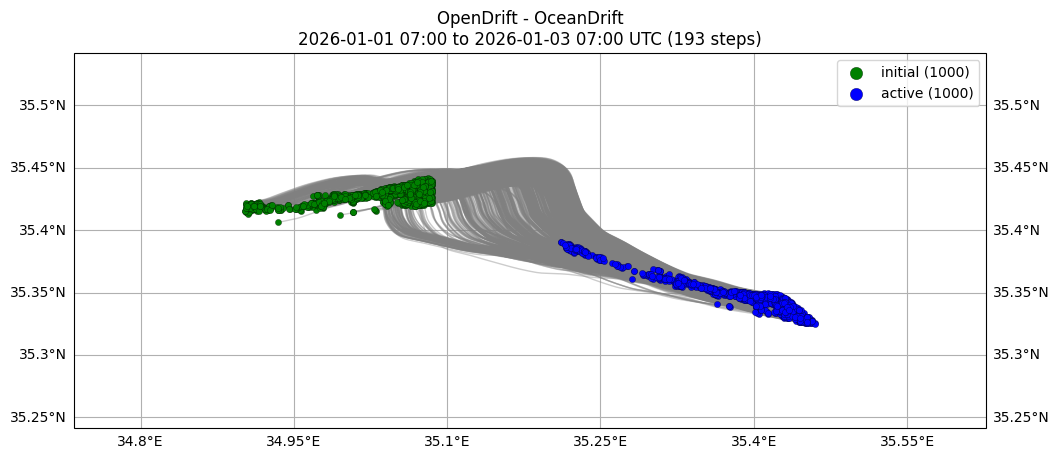

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2026-01-01 07:00 to 2026-01-03 07:00 UTC (193 steps)'}>,
 <Figure size 1100x454.185 with 1 Axes>)

In [24]:
o.plot()

In [25]:
o.animation()

20:20:03 INFO    opendrift:3155: Preparing animation for notebook....


20:48:53 INFO    opendrift:3128: Time to make animation: 0:28:53.420536


In [ ]:
# ── Step 8: Visualize ─────────────────────────────────────────────────────
# Use quick_render=True for fast animation, False for high quality
visualize(o, quick_render=True)  # Set to False for publication-quality animation

NameError: name 'visualize' is not defined

## Animation Performance Tuning Guide

**Current optimizations applied:**
- Particle count: 300 (was 1000) → ~70% faster simulation
- Time step: 1800s/30min (was 900s/15min) → ~2x fewer frames
- Animation mode: quick_render=True → lower DPI, smaller markers, reduced fps

**Performance vs Quality Trade-offs:**

| Setting | Speed | Quality | Use Case |
|---------|-------|---------|----------|
| NUM_PARTICLES=300, time_step=1800, quick_render=True | ⚡⚡⚡ Fastest | Good | Quick iteration, testing |
| NUM_PARTICLES=500, time_step=1200, quick_render=False | ⚡⚡ Fast | High | Presentations |
| NUM_PARTICLES=1000, time_step=900, quick_render=False | ⚡ Normal | Best | Publication |

**To adjust further:**
- Reduce `NUM_PARTICLES` to 100-200 for even faster rendering
- Reduce `duration=timedelta(hours=24)` to test over fewer hours
- Set `quick_render=True` for draft mode during development

20:50:28 WARNING py.warnings:109: C:\Users\HP\Documents\GitHub\Final-Year-Project\Codebase\env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)



=== BASIC INFO ===
Image shape : (2, 2048, 2048)  (bands, rows, cols)
Mask shape  : (2048, 2048)
Shapes match: True

Image dtype : float32
Mask dtype  : uint8

Image value range: -33.61658477783203 → 9.04831600189209
Mask value range : 0 → 1
Unique mask values: [0 1]


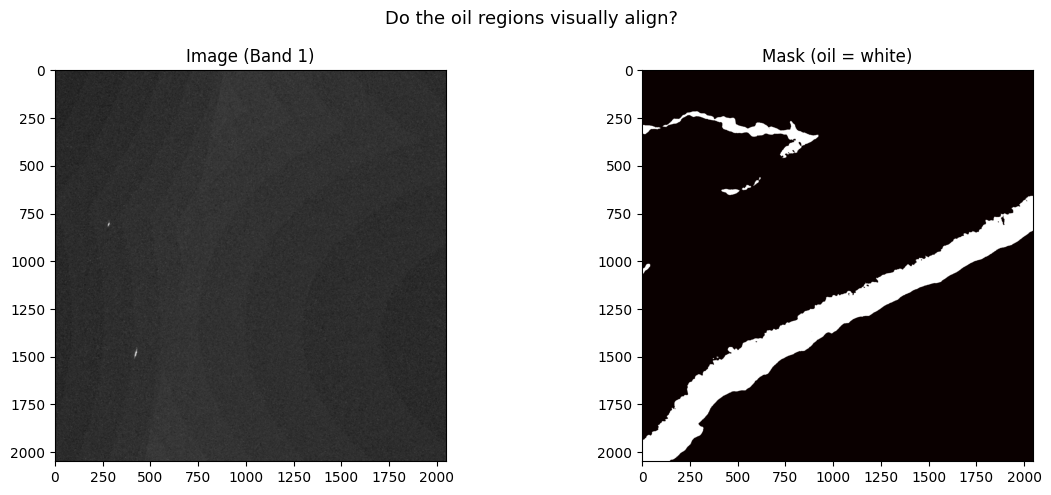


Saved → image_vs_mask_check.png


In [26]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = r"E:\Final_yr project dataset\Dataset-OG\Test\Images\Oil\00003.tif"
MASK_PATH  = r"E:\Final_yr project dataset\Dataset-OG\Test\Mask\Oil\00003_segmentation.tif"

# ── Read both ─────────────────────────────────────────────────────────────
with rasterio.open(IMAGE_PATH) as img:
    image_data = img.read()          # all bands
    image_transform = img.transform
    image_crs = img.crs
    image_shape = img.shape

with rasterio.open(MASK_PATH) as msk:
    mask_data = msk.read(1)          # single band
    mask_shape = msk.shape

print("=== BASIC INFO ===")
print(f"Image shape : {image_data.shape}  (bands, rows, cols)")
print(f"Mask shape  : {mask_shape}")
print(f"Shapes match: {image_shape == mask_shape}")

print(f"\nImage dtype : {image_data.dtype}")
print(f"Mask dtype  : {mask_data.dtype}")

print(f"\nImage value range: {image_data.min()} → {image_data.max()}")
print(f"Mask value range : {mask_data.min()} → {mask_data.max()}")
print(f"Unique mask values: {np.unique(mask_data)}")

# ── Plot side by side ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Image — show first band or RGB
if image_data.shape[0] >= 3:
    rgb = np.stack([image_data[0], image_data[1], image_data[2]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())  # normalize
    axes[0].imshow(rgb)
    axes[0].set_title("Image (RGB)")
else:
    axes[0].imshow(image_data[0], cmap='gray')
    axes[0].set_title("Image (Band 1)")

# Mask
axes[1].imshow(mask_data, cmap='hot')
axes[1].set_title("Mask (oil = white)")

plt.suptitle("Do the oil regions visually align?", fontsize=13)
plt.tight_layout()
plt.savefig("image_vs_mask_check.png", dpi=150)
plt.show()

print("\nSaved → image_vs_mask_check.png")

In [46]:
import rasterio
import numpy as np

# ── Define paths (same as in your notebook) ──────────────────────────────
IMAGE_PATH = r"E:\Final_yr project dataset\Dataset-OG\Test\Images\Oil\00003.tif"
MASK_PATH  = r"E:\Final_yr project dataset\Dataset-OG\Test\Mask\Oil\00003_segmentation.tif"

# ── Check both files independently ───────────────────────────────────────
with rasterio.open(IMAGE_PATH) as img:
    print("=== IMAGE ===")
    print("CRS:      ", img.crs)
    print("Transform:", img.transform)
    print("Shape:    ", img.shape)
    print("Bounds:   ", img.bounds)

with rasterio.open(MASK_PATH) as msk:
    print("\n=== MASK ===")
    print("CRS:      ", msk.crs)
    print("Transform:", msk.transform)
    print("Shape:    ", msk.shape)
    print("Bounds:   ", msk.bounds)

'''# ── Re-extract spill pixels cleanly (using MASK's own transform) ─────────
with rasterio.open(MASK_PATH) as msk:
    mask_data  = msk.read(1) > 0
    transform  = msk.transform
    crs        = msk.crs

rows, cols = np.where(mask_data)
spill_pixels = np.array([
    rasterio.transform.xy(transform, r, c)
    for r, c in zip(rows, cols)
])'''

print("\n=== SPILL PIXEL COORDS (first 5) ===")
print(spill_pixels[:5])

print("\n=== COORDINATE RANGE ===")
print(f"Lon: {spill_pixels[:, 0].min():.4f} → {spill_pixels[:, 0].max():.4f}")
print(f"Lat: {spill_pixels[:, 1].min():.4f} → {spill_pixels[:, 1].max():.4f}")

print("\n=== BOUNDING BOX THAT WOULD BE SENT TO COPERNICUS ===")
min_lon = float(np.min(spill_pixels[:, 0])) - 0.5
max_lon = float(np.max(spill_pixels[:, 0])) + 0.5
min_lat = float(np.min(spill_pixels[:, 1])) - 0.5
max_lat = float(np.max(spill_pixels[:, 1])) + 0.5
print(f"Lon: {min_lon} → {max_lon}")
print(f"Lat: {min_lat} → {max_lat}")

# ── Sanity check: should be near (34.9–35.1°E, 35.38–35.46°N) ───────────
expected_lon = (34.5, 35.5)
expected_lat = (34.9, 35.9)
lon_ok = expected_lon[0] < spill_pixels[:, 0].mean() < expected_lon[1]
lat_ok = expected_lat[0] < spill_pixels[:, 1].mean() < expected_lat[1]
print("\n=== SANITY CHECK ===")
print(f"Lon looks correct: {lon_ok}")
print(f"Lat looks correct: {lat_ok}")
if not lon_ok or not lat_ok:
    print("⚠️  Coordinates are NOT in expected range — likely a CRS/projection issue!")
    print("    CRS needs reprojection to EPSG:4326 before use.")
else:
    print("✅  Coordinates look correct for Eastern Mediterranean.")

=== IMAGE ===
CRS:       EPSG:4326
Transform: | 0.00, 0.00, 38.13|
| 0.00,-0.00, 20.25|
| 0.00, 0.00, 1.00|
Shape:     (2048, 2048)
Bounds:    BoundingBox(left=38.12621276770311, bottom=20.069581939823465, right=38.310187737890786, top=20.25355691001114)

=== MASK ===
CRS:       None
Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Shape:     (2048, 2048)
Bounds:    BoundingBox(left=0.0, bottom=2048.0, right=2048.0, top=0.0)

=== SPILL PIXEL COORDS (first 5) ===
[[35.0772944  35.44202175]
 [35.08052834 35.44202175]
 [35.08061817 35.44202175]
 [35.080708   35.44202175]
 [35.07711474 35.44193191]]

=== COORDINATE RANGE ===
Lon: 34.9019 → 35.0857
Lat: 35.4044 → 35.4420

=== BOUNDING BOX THAT WOULD BE SENT TO COPERNICUS ===
Lon: 34.40185342819357 → 35.58573856685283
Lat: 34.90438233606676 → 35.94202174647137

=== SANITY CHECK ===
Lon looks correct: True
Lat looks correct: True
✅  Coordinates look correct for Eastern Mediterranean.
